In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import numpy as np

from typing import Literal

# Classe da MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self, n_neuronios: list, hidden_activation: Literal["Tanh","ReLU"] = "ReLU", dropout_probability: float = 0.0) -> None:
        super().__init__()

        if len(n_neuronios) < 2:
            raise ValueError("A MLP precisa de pelo menos 2 quantidades de neurônios (tamanho de entrada e tamanho de saída)")

        self.dropout_probability = dropout_probability
        self.activation = hidden_activation
        self.layers = nn.ModuleList()
        for i, neuronios in enumerate(n_neuronios):
          if i < len(n_neuronios) - 1:
            self.layers.append(nn.Linear(neuronios, n_neuronios[i+1]))

    def forward(self, x):
        for _, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            if self.dropout_probability > 0:
                x = F.dropout(x, p=self.dropout_probability, training=self.training)
                x = F.relu(x) # todas as camadas tem função de ativação ReLU
        # Última camada (output) sem ativação
        x = self.layers[-1](x)
        return x

# Funções de Treino e Validação

In [ ]:
from typing import NamedTuple

class Data(NamedTuple):
  inputs: torch.Tensor
  labels: torch.Tensor

In [ ]:
def accuracy_binary(outputs, labels):
    preds = (outputs > 0) # threshold para binarização das predições, 0 para logits

    if labels.dim() == 2 and labels.shape[1] == 1:
        processed_labels = labels.squeeze(1)
    elif labels.dim() == 1:
        processed_labels = labels
    else:
        raise ValueError(f"Dimensão inesperada para labels: {labels.shape}")

    preds = preds.squeeze(1)

    # interpretamos a label -1 como 0
    processed_labels = torch.where(processed_labels == -1, torch.tensor(0.0), processed_labels.float())

    return torch.sum(preds == processed_labels).item() / len(preds)

In [ ]:
def accuracy_multiclass(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    if labels.dim() == 2 and labels.shape[1] == 1:
        labels = labels.squeeze(1)
    return torch.sum(preds == labels).item() / len(preds)

In [ ]:
def validate_one_epoch(modelo, loss, val_data: Data, batch_size: int, epoch_index: int, verbose=False):
  num_samples = len(val_data.inputs)
  num_batches = (num_samples + batch_size - 1) // batch_size

  total_loss = 0.0
  total_accuracy = 0.0

  # desativamos o gradiente
  with torch.no_grad():
    # para cada batch de dados de validação
    for batch_idx in range(num_batches):
      start_idx = batch_idx * batch_size
      end_idx = min((batch_idx + 1) * batch_size, num_samples)
      inputs = val_data.inputs[start_idx:end_idx]
      labels = val_data.labels[start_idx:end_idx]


      if isinstance(loss, nn.BCEWithLogitsLoss):
        if labels.dim() == 1:
            labels = labels.unsqueeze(1)
        labels = labels.clone()
        labels[labels == -1] = 0.0 # Converter labels de -1/1 para 0/1, para funcionar com BCEWithLogitsLoss
      elif isinstance(loss, nn.CrossEntropyLoss):
        if labels.dim() == 2:
            labels = labels.squeeze(1)
        labels = labels.long()

      # fazemos uma predição e calculamos sua loss e acurácia
      outputs = modelo(inputs)
      l = loss(outputs, labels)

      current_batch_loss_item = l.item()
      if labels.dim() == 2 and labels.shape[1] == 1:
        current_batch_accuracy = accuracy_binary(outputs, labels)
      else:
        current_batch_accuracy = accuracy_multiclass(outputs, labels)

      if verbose:
        print(f'  batch {batch_idx + 1} loss: {current_batch_loss_item:.4f}')

      total_loss += current_batch_loss_item
      total_accuracy += current_batch_accuracy

  return total_loss / num_batches, total_accuracy / num_batches

In [ ]:
def train_one_epoch(modelo, loss, otimizador, train_data: Data, batch_size: int, epoch_index: int, l2_lambda: float = 0.0, verbose=False):
  num_samples = len(train_data.inputs)
  num_batches = (num_samples + batch_size - 1) // batch_size

  total_loss = 0.0
  total_accuracy = 0.0

  # para cada batch de dados de treino
  for batch_idx in range(num_batches):
    start_idx = batch_idx * batch_size
    end_idx = min((batch_idx + 1) * batch_size, num_samples)
    inputs = train_data.inputs[start_idx:end_idx]
    labels = train_data.labels[start_idx:end_idx]

    if isinstance(loss, nn.BCEWithLogitsLoss):
        if labels.dim() == 1:
            labels = labels.unsqueeze(1)
        labels = labels.clone()
        labels[labels == -1] = 0.0 # Converter labels de -1/1 para 0/1, para funcionar com BCEWithLogitsLoss
    elif isinstance(loss, nn.CrossEntropyLoss):
        if labels.dim() == 2:
            labels = labels.squeeze(1)
        labels = labels.long()

    otimizador.zero_grad() # zeramos o gradiente para o batch
    outputs = modelo(inputs) # fazemos uma predição

    # computamos a loss e seu gradiente (com regularização l2 opcional)
    l = loss(outputs, labels)
    if l2_lambda > 0:
      l += l2_lambda * sum(p.pow(2).sum() for p in modelo.parameters())
    l.backward()

    # ajustamos o otimizador
    otimizador.step()

    # registramos a loss e a acurácia da batch
    current_batch_loss = l.item()
    if labels.dim() == 2 and labels.shape[1] == 1:
      current_batch_accuracy = accuracy_binary(outputs, labels)
    else:
      current_batch_accuracy = accuracy_multiclass(outputs, labels)

    if verbose:
      print(f'  batch {batch_idx + 1} loss: {current_batch_loss:.4f}')

    total_loss += current_batch_loss
    total_accuracy += current_batch_accuracy

  if verbose:
    print(f'Loss: {total_loss:.4f}')

  return total_loss / num_batches, total_accuracy / num_batches

In [ ]:
def train(modelo, loss, otimizador, train_data: Data, batch_size: int, epochs: int, val_data: Data = None, early_stopping_patience: int = None, l2_lambda: float = 0.0, verbose=False):
  log = {}

  if early_stopping_patience:
    if not val_data:
      raise ValueError("Early stopping precisa de um conjunto de validação")
    last_val_loss = float("inf")
    current_patience = early_stopping_patience

  for epoch_num in range(1, epochs+1):
    if verbose:
      print('EPOCH {}'.format(epoch_num))
    log[epoch_num] = {}

    modelo.train(True)
    train_loss, train_accuracy = train_one_epoch(modelo, loss, otimizador, train_data, batch_size, epoch_num, l2_lambda, verbose)

    log[epoch_num]["train_loss"] = train_loss
    log[epoch_num]["train_accuracy"] = train_accuracy

    if val_data:
      modelo.eval()
      val_loss, val_accuracy = validate_one_epoch(modelo, loss, val_data, batch_size, epoch_num, verbose)

      log[epoch_num]["val_loss"] = val_loss
      log[epoch_num]["val_accuracy"] = val_accuracy

      if early_stopping_patience:
        if val_loss < last_val_loss:
          last_val_loss = val_loss
          current_patience = early_stopping_patience
        else:
          current_patience -= 1
          if current_patience == 0:
            print("Early stopping")
            break
    if verbose:
      print()
  return log

# Testes

## Funções auxiliares

In [ ]:
def create_dataset(data_path: str) -> Data:
  df = pd.read_csv(data_path)
  inputs = torch.Tensor(df.iloc[:,:-1].values)
  labels = torch.Tensor(df.iloc[:,-1].values)
  return Data(inputs=inputs, labels=labels)

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
  epochs = list(history.keys())
  train_losses = [history[epoch]["train_loss"] for epoch in epochs]
  train_accuracies = [history[epoch]["train_accuracy"] for epoch in epochs]
  val_losses = [history[epoch]["val_loss"] for epoch in epochs if "val_loss" in history[epoch]]
  val_accuracies = [history[epoch]["val_accuracy"] for epoch in epochs if "val_accuracy" in history[epoch]]

  plt.figure(figsize=(8, 4))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, train_losses, label='Train Loss')
  if val_losses:
      plt.plot(epochs, val_losses, label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.title(f'Training {"and Validation " if val_losses else ""}Loss')
  plt.grid(True)
  plt.tight_layout()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, train_accuracies, label='Train Accuracy')
  if val_accuracies:
      plt.plot(epochs, val_accuracies, label='Validation Accuracy')
      plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.ylim(0, 1.05)
  plt.legend()
  plt.title(f'Training {"and Validation " if val_accuracies else ""}Accuracy')
  plt.grid(True)
  plt.tight_layout()

In [ ]:
import matplotlib.patches as mpatches

def plot_decision_boundary(
    model,
    X: np.ndarray,
    y: np.ndarray,
    resolution: float = 0.01,
    margin: float = 0.5,
    figsize: tuple = (8, 6),
    title: str = "Fronteira de Decisão"
):
    # Grade cobrindo o espaço de entrada
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.arange(x_min, x_max, resolution),
                         np.arange(y_min, y_max, resolution))

    # Inferência sobre a grade
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32))
    scores = out.squeeze().numpy().reshape(xx.shape)

    # PLotando -----------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    ax.contourf(xx, yy, scores, levels=50, cmap="RdBu", alpha=0.35)
    ax.contour(xx, yy, np.sign(scores), levels=[0],
               colors="black", linewidths=1.5, linestyles="--")

    colors = {1: "#008000", -1: "#800080"}

    for label, color in colors.items():
        mask = y == label
        ax.scatter(X[mask, 0], X[mask, 1], c=color,
                   edgecolors="white", linewidths=0.6, s=60, zorder=3)

    ax.legend(handles=[mpatches.Patch(color=c, label=str(l)) for l, c in colors.items()],
              loc="best", framealpha=0.7)
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max),
           xlabel="x1", ylabel="x2", title=title, aspect="equal")

    plt.tight_layout()
    return fig, ax

## Dataset 1

In [ ]:
test_path1 = "/content/test_dataset1.csv"
train_path1 = "/content/train_dataset1.csv"

In [ ]:
test_data1 = create_dataset(test_path1)
train_data1 = create_dataset(train_path1)

### Com função de ativação Tanh

In [ ]:
torch.manual_seed(0)

modelo1 = MLP([2, 2, 1], hidden_activation="Tanh")

otimizador1 = optim.SGD(modelo1.parameters(), lr=0.01)
loss1 = nn.BCEWithLogitsLoss()

display(modelo1)

history1 = train(
    modelo=modelo1,
    loss=loss1,
    otimizador=otimizador1,
    train_data=train_data1,
    batch_size=15,
    epochs=100,
    verbose=False
)

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Linear(in_features=2, out_features=1, bias=True)
  )
)

Acurácia no conjunto de teste: 0.9500


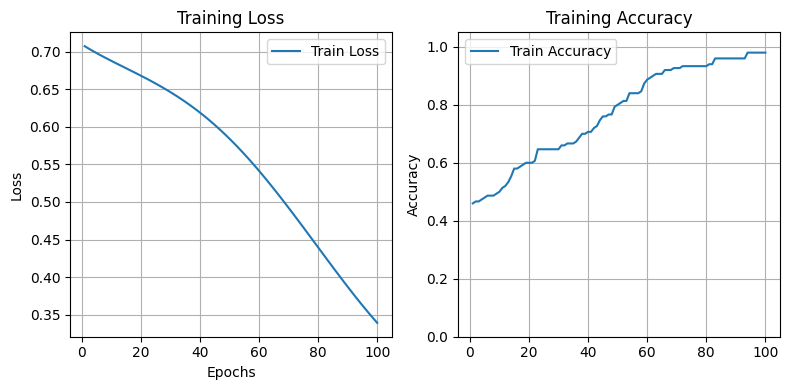

In [ ]:
plot_history(history1)

modelo1.eval()
test_output1 = modelo1(test_data1.inputs)

test_accuracy1 = accuracy_binary(test_output1, test_data1.labels)
print(f"Acurácia no conjunto de teste: {test_accuracy1:.4f}")

#### Visualização da fronteira de decisão

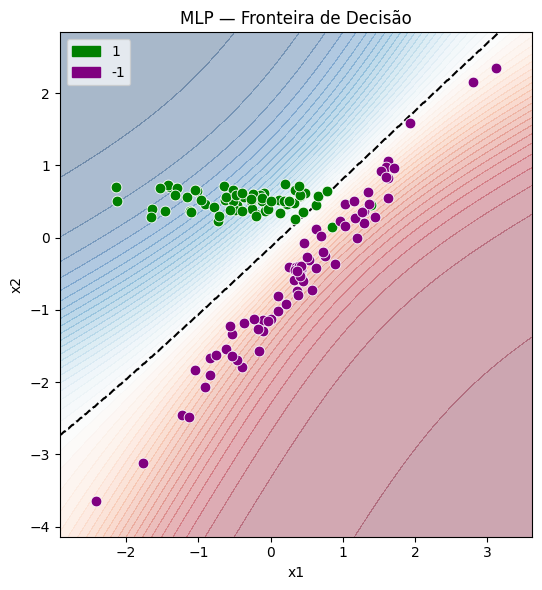

In [ ]:
fig, ax = plot_decision_boundary(
    model=modelo1,
    X=train_data1.inputs.numpy(),
    y=train_data1.labels.numpy().squeeze(),
    resolution=0.01,
    title="MLP — Fronteira de Decisão",
)
plt.show()

### Com função de ativação ReLU

In [ ]:
torch.manual_seed(0)

modelo1 = MLP([2, 2, 1], hidden_activation="ReLU")

otimizador1 = optim.SGD(modelo1.parameters(), lr=0.01)
loss1 = nn.BCEWithLogitsLoss()

display(modelo1)

history1 = train(
    modelo=modelo1,
    loss=loss1,
    otimizador=otimizador1,
    train_data=train_data1,
    batch_size=15,
    epochs=100,
    verbose=False
)

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=2, bias=True)
    (1): Linear(in_features=2, out_features=1, bias=True)
  )
)

Acurácia no conjunto de teste: 0.9500


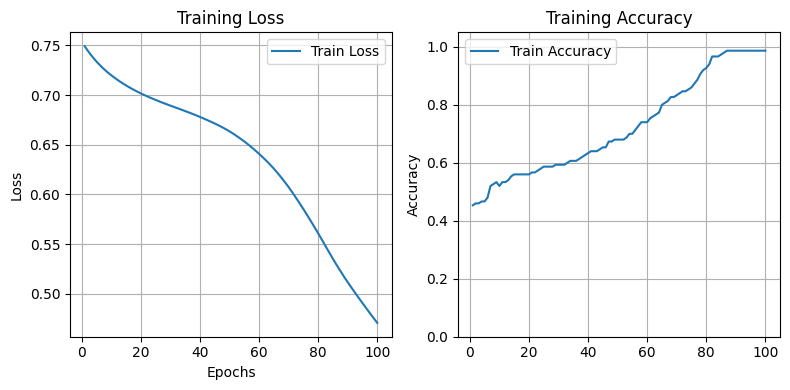

In [ ]:
plot_history(history1)

modelo1.eval()
test_output1 = modelo1(test_data1.inputs)

test_accuracy1 = accuracy_binary(test_output1, test_data1.labels)
print(f"Acurácia no conjunto de teste: {test_accuracy1:.4f}")

#### Visualização da fronteira de decisão

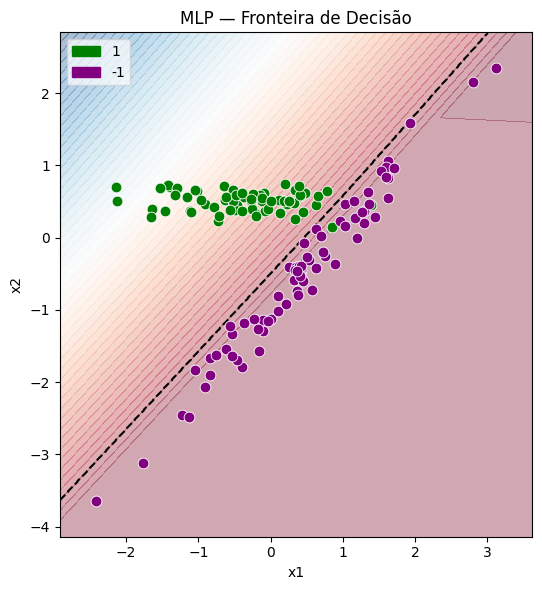

In [ ]:
fig, ax = plot_decision_boundary(
    model=modelo1,
    X=train_data1.inputs.numpy(),
    y=train_data1.labels.numpy().squeeze(),
    resolution=0.01,       # grade mais fina = fronteira mais suave
    title="MLP — Fronteira de Decisão",
)
plt.show()

## Dataset 2

In [ ]:
test_path2 = "/content/test_dataset2.csv"
train_path2 = "/content/train_dataset2.csv"

In [ ]:
test_data2 = create_dataset(test_path2)
train_data2 = create_dataset(train_path2)

In [ ]:
torch.manual_seed(0)

modelo2 = MLP([2, 4, 1], hidden_activation="ReLU")

otimizador2 = optim.SGD(modelo2.parameters(), lr=0.002)
loss2 = nn.BCEWithLogitsLoss()

display(modelo2)

history2 = train(
    modelo=modelo2,
    loss=loss2,
    otimizador=otimizador2,
    train_data=train_data2,
    batch_size=15,
    epochs=200,
    l2_lambda=0.001,
    verbose=False
)

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Linear(in_features=4, out_features=1, bias=True)
  )
)

Acurácia no conjunto de teste: 0.8667


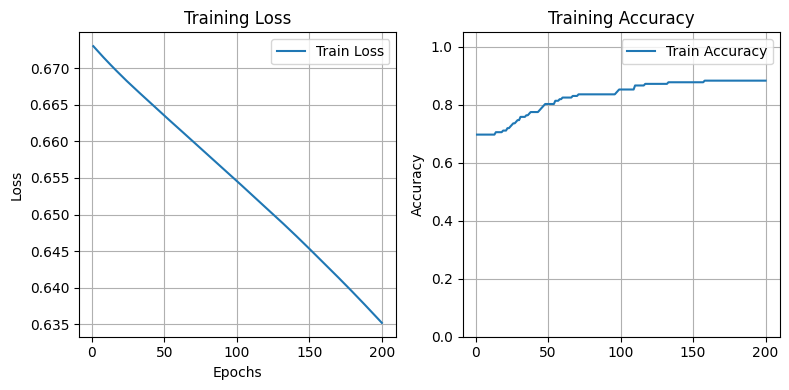

In [ ]:
plot_history(history2)

modelo2.eval()
test_output2 = modelo2(test_data2.inputs)

test_accuracy2 = accuracy_binary(test_output2, test_data2.labels)
print(f"Acurácia no conjunto de teste: {test_accuracy2:.4f}")

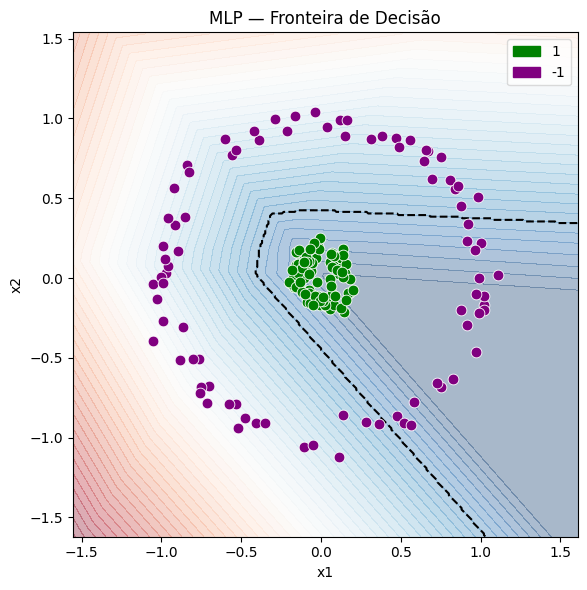

In [ ]:
fig, ax = plot_decision_boundary(
    model=modelo2,
    X=train_data2.inputs.numpy(),
    y=train_data2.labels.numpy().squeeze(),
    resolution=0.01,
    title="MLP — Fronteira de Decisão",
)
plt.show()

Podemos ver que a fronteira de decisão quase consegue separar as classes "interna" 1 e "externa" -1. Vamos experimentar aumentar a complexidade do modelo, adicionando mais uma camada, para chegar em uma fronteira melhor.

In [ ]:
torch.manual_seed(0)

modelo2 = MLP([2, 4, 3, 1], hidden_activation="ReLU")

otimizador2 = optim.SGD(modelo2.parameters(), lr=0.005)
loss2 = nn.BCEWithLogitsLoss()

display(modelo2)

history2 = train(
    modelo=modelo2,
    loss=loss2,
    otimizador=otimizador2,
    train_data=train_data2,
    batch_size=15,
    epochs=900,
    l2_lambda=0.001,
    verbose=False
)

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Linear(in_features=4, out_features=3, bias=True)
    (2): Linear(in_features=3, out_features=1, bias=True)
  )
)

Acurácia no conjunto de teste: 1.0000


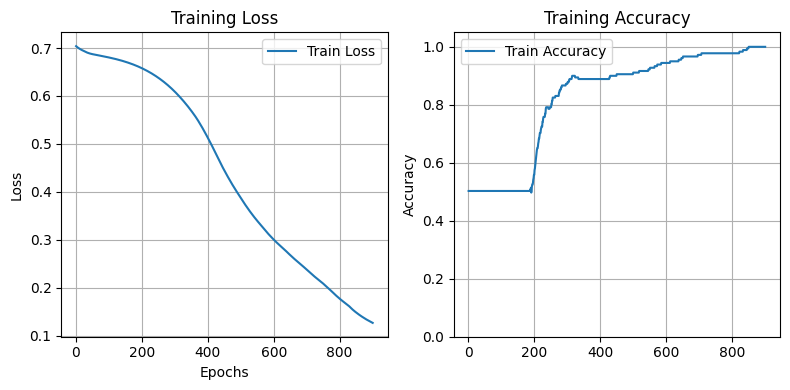

In [ ]:
plot_history(history2)

modelo2.eval()
test_output2 = modelo2(test_data2.inputs)

test_accuracy2 = accuracy_binary(test_output2, test_data2.labels)
print(f"Acurácia no conjunto de teste: {test_accuracy2:.4f}")

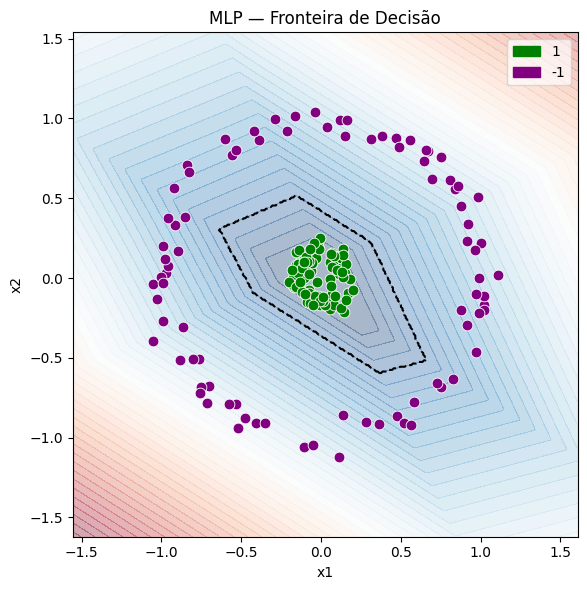

In [ ]:
fig, ax = plot_decision_boundary(
    model=modelo2,
    X=train_data2.inputs.numpy(),
    y=train_data2.labels.numpy().squeeze(),
    resolution=0.01,
    title="MLP — Fronteira de Decisão",
)
plt.show()

A adição de mais uma camada também necessitou de um aumento considerável na quantidade de épocas de treinamento, mas conseguimos chegar a uma separação perfeita do conjunto de teste.

---

Podemos verificar que o aumento de complexidade é vantajoso, pois ao executar (abaixo) um novo teste com a configuração original, vemos que a quantidade de épocas necessárias para se chegar a uma separação comparável aumenta consideravelmente (de 900 para 1100, mantendo os demais hiperparâmetros fixos), e a fronteira é menos bem definida.

In [ ]:
torch.manual_seed(0)

modelo2 = MLP([2, 4, 1], hidden_activation="ReLU")

otimizador2 = optim.SGD(modelo2.parameters(), lr=0.005)
loss2 = nn.BCEWithLogitsLoss()

display(modelo2)

history2 = train(
    modelo=modelo2,
    loss=loss2,
    otimizador=otimizador2,
    train_data=train_data2,
    batch_size=15,
    epochs=1100,
    l2_lambda=0.001,
    verbose=False
)

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Linear(in_features=4, out_features=1, bias=True)
  )
)

Acurácia no conjunto de teste: 1.0000


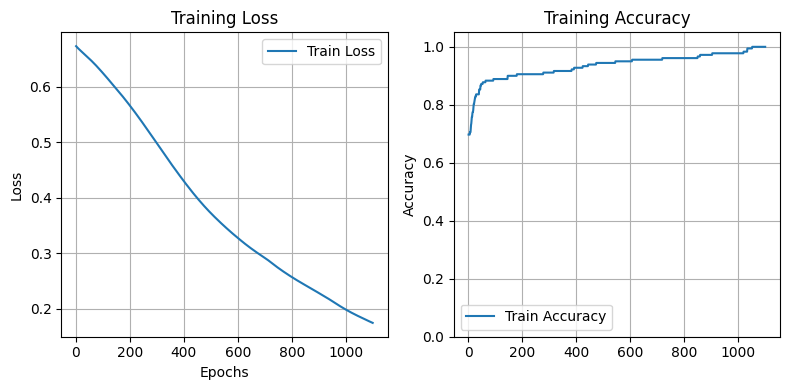

In [ ]:
plot_history(history2)

modelo2.eval()
test_output2 = modelo2(test_data2.inputs)

test_accuracy2 = accuracy_binary(test_output2, test_data2.labels)
print(f"Acurácia no conjunto de teste: {test_accuracy2:.4f}")

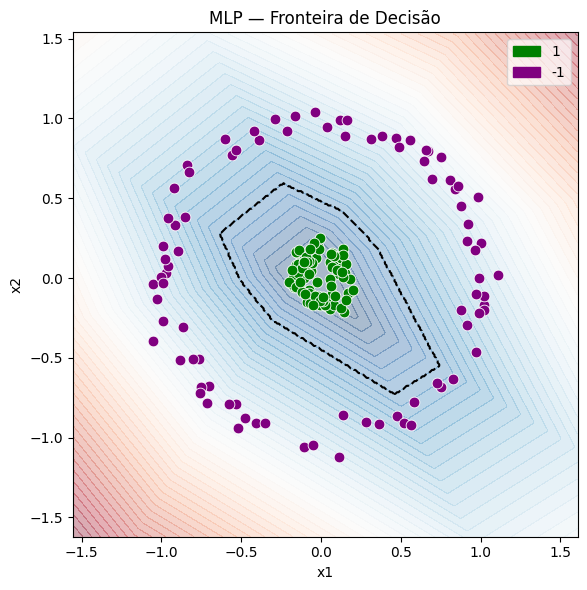

In [ ]:
fig, ax = plot_decision_boundary(
    model=modelo2,
    X=train_data2.inputs.numpy(),
    y=train_data2.labels.numpy().squeeze(),
    resolution=0.01,
    title="MLP — Fronteira de Decisão",
)
plt.show()

# Testando com a função Tanh

In [ ]:
torch.manual_seed(0)

modelo2 = MLP([2, 4, 3, 1], hidden_activation="Tanh")

otimizador2 = optim.SGD(modelo2.parameters(), lr=0.005)
loss2 = nn.BCEWithLogitsLoss()

display(modelo2)

history2 = train(
    modelo=modelo2,
    loss=loss2,
    otimizador=otimizador2,
    train_data=train_data2,
    batch_size=15,
    epochs=450,
    l2_lambda=0.001,
    verbose=False
)

MLP(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Linear(in_features=4, out_features=3, bias=True)
    (2): Linear(in_features=3, out_features=1, bias=True)
  )
)

Acurácia no conjunto de teste: 0.6667


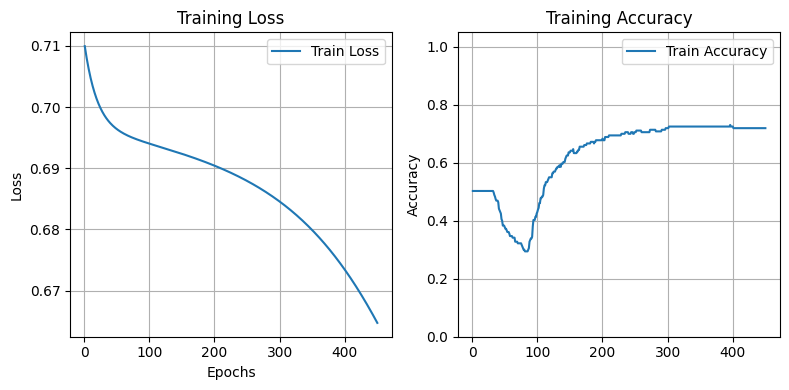

In [ ]:
plot_history(history2)

modelo2.eval()
test_output2 = modelo2(test_data2.inputs)

test_accuracy2 = accuracy_binary(test_output2, test_data2.labels)
print(f"Acurácia no conjunto de teste: {test_accuracy2:.4f}")

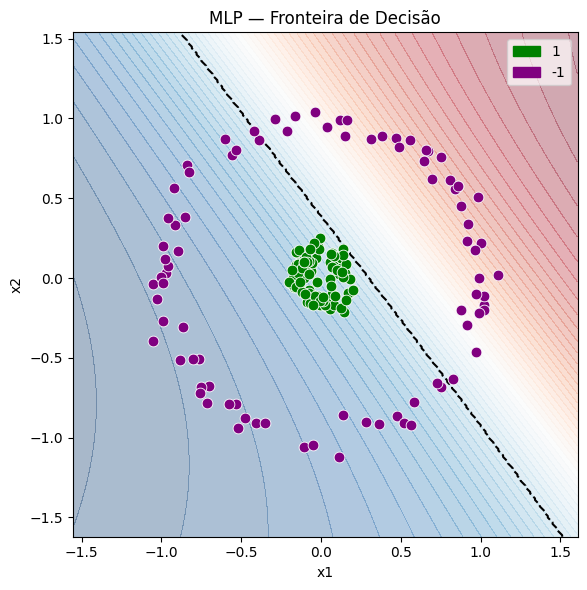

In [ ]:
fig, ax = plot_decision_boundary(
    model=modelo2,
    X=train_data2.inputs.numpy(),
    y=train_data2.labels.numpy().squeeze(),
    resolution=0.01,
    title="MLP — Fronteira de Decisão",
)
plt.show()

Percebe-se que alterar a função de ativação muda completamente a fronteira de decisão traçada. Toda uma nova experimentação seria necessária, provavelmente com uma rede mais complexa.

## Dataset 4

In [ ]:
test_path4 = "/content/test_dataset4.csv"
train_path4 = "/content/train_dataset4.csv"
val_path4 = "/content/validation_dataset4.csv"

In [ ]:
df_train_loaded = pd.read_csv(train_path4)
df_val_loaded = pd.read_csv(val_path4)
df_test_loaded = pd.read_csv(test_path4)

In [ ]:
df_train = pd.read_csv(train_path4)
df_val   = pd.read_csv(val_path4)
df_test  = pd.read_csv(test_path4)

def df_to_data(df: pd.DataFrame) -> Data:
    X = torch.Tensor(df.drop("label", axis=1).values)
    y = torch.Tensor(df["label"].values)
    return Data(inputs=X, labels=y)

train_data4 = df_to_data(df_train)
val_data4   = df_to_data(df_val)
test_data4  = df_to_data(df_test)

print("Shapes:")
print(f"\ttrain: X={train_data4.inputs.shape}  y={train_data4.labels.shape}")
print(f"\tval X={val_data4.inputs.shape}  y={val_data4.labels.shape}")
print(f"\ttest X={test_data4.inputs.shape}  y={test_data4.labels.shape}")

Shapes:
	train: X=torch.Size([768, 50])  y=torch.Size([768])
	val X=torch.Size([192, 50])  y=torch.Size([192])
	test X=torch.Size([240, 50])  y=torch.Size([240])


### Funções auxiliares para percorrer as combinações

In [ ]:
from typing import TypedDict

class ExperimentResult(TypedDict):
    config: dict
    history: dict
    test_accuracy: float
    label: str

In [ ]:
def make_label(cfg: dict) -> str:
    return (
        f"{cfg['arquitetura']}\n"
        f"{cfg['ativacao']} | {cfg['otimizador']} lr={cfg['lr']}\n"
        f"dropout={cfg['dropout']} L2={cfg['l2_lambda']}"
    )

In [ ]:
import itertools

SEARCH_SPACE = {
    "arquitetura":  [
        [50, 64, 4],
        [50, 128, 64, 4],
        [50, 256, 128, 64, 4],
    ],
    "ativacao": ["ReLU", "Tanh"],
    "dropout": [0.0, 0.1],        # 0.0 é sem
    "otimizador": ["SGD", "Adam"],
    "lr": [0.01, 0.001],
    "l2_lambda": [0.0, 0.001],    # 0.0 é sem
}

# Mapeamento do nome para a classe do otimizador
OTIMIZADORES = {"SGD": optim.SGD, "Adam": optim.Adam}


def run_experiments(search_space: dict) -> list[ExperimentResult]:
    """
    Executa todos os experimentos definidos pelo produto cartesiano
    de search_space e devolve uma lista de ExperimentResult.
    """
    keys = list(search_space.keys())
    values = list(search_space.values())
    combs = list(itertools.product(*values))

    print(f"Total de experimentos: {len(combs)}\n")
    results = []

    for i, comb in enumerate(combs, 1):
        cfg = dict(zip(keys, comb))

        print(f"[{i}/{len(combs)}] {cfg}")

        # Instancia um modelo novo a cada experimento, com seed fixa para comparação e reprodutibilidade
        torch.manual_seed(0)
        modelo = MLP(
            n_neuronios=cfg["arquitetura"],
            hidden_activation=cfg["ativacao"],
            dropout_probability=cfg["dropout"],
        )

        otimizador_cls = OTIMIZADORES[cfg["otimizador"]]
        otimizador = otimizador_cls(modelo.parameters(), lr=cfg["lr"])

        history = train(
            modelo=modelo,
            loss=nn.CrossEntropyLoss(),
            otimizador=otimizador,
            train_data=train_data4,
            val_data=val_data4,
            batch_size=32,
            epochs=100,
            l2_lambda=cfg["l2_lambda"],
            early_stopping_patience=20,
            verbose=False,
        )

        modelo.eval()
        with torch.no_grad():
            test_out = modelo(test_data4.inputs)
        test_acc = accuracy_multiclass(test_out, test_data4.labels)

        results.append({"config": cfg, "history": history, "test_accuracy": test_acc, "label": make_label(cfg)})
        print(f"\t - test accuracy: {test_acc:.4f}\n")

    return results

### Execução e visualização

In [ ]:
def plot_comparison(
    results: list[dict],
    cols: int = 4,
    metric: Literal["loss", "accuracy"] = "loss",
) -> None:
    """
    Plota loss ou acurácia de treino/validação para cada experimento,
    organizados em grade.  Destaca o melhor modelo (maior test_accuracy)
    com borda verde.
    """
    results = sorted(results, key=lambda r: (
        str(r["config"]["arquitetura"]),
        r["config"]["otimizador"],
        r["config"]["lr"],
        r["config"]["ativacao"],
        r["config"]["dropout"],
        r["config"]["l2_lambda"],
    ))

    best_idx = max(range(len(results)), key=lambda i: results[i]["test_accuracy"])
    n = len(results)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5))
    axes_flat = axes.flatten() if n > 1 else [axes]

    train_key = f"train_{metric}"
    val_key = f"val_{metric}"
    y_label = "Loss" if metric == "loss" else "Accuracy"

    for idx, (ax, res) in enumerate(zip(axes_flat, results)):
        epochs = list(res["history"].keys())
        train_values = [res["history"][e][train_key] for e in epochs]
        val_values = [res["history"][e][val_key] for e in epochs if val_key in res["history"][e]]

        ax.plot(epochs, train_values, label=f"Train {y_label}")
        if val_values:
            ax.plot(epochs[: len(val_values)], val_values, label=f"Val {y_label}")

        ax.set_title(f"{res['label']}\ntest_acc={res['test_accuracy']:.4f}", fontsize=7)
        ax.set_xlabel("Épocas", fontsize=7)
        ax.set_ylabel(y_label, fontsize=7)
        ax.legend(fontsize=6)
        ax.grid(True, alpha=0.4)
        ax.tick_params(labelsize=7)

        if metric == "accuracy":
            ax.set_ylim(0, 1.05)

        if idx == best_idx:
            for spine in ax.spines.values():
                spine.set_edgecolor("green")
                spine.set_linewidth(2.5)

    for ax in axes_flat[n:]:
        ax.set_visible(False)

    fig.suptitle(
        f"Comparação de Experimentos — Dataset 4 ({y_label})\n"
        f"Melhor modelo (borda verde): test_acc={results[best_idx]['test_accuracy']:.4f}",
        fontsize=10,
        y=1,
    )
    plt.tight_layout()
    plt.show()

In [ ]:
results4 = run_experiments(SEARCH_SPACE)

Total de experimentos: 96

[1/96] {'arquitetura': [50, 64, 4], 'ativacao': 'ReLU', 'dropout': 0.0, 'otimizador': 'SGD', 'lr': 0.01, 'l2_lambda': 0.0}
Early stopping
	 - test accuracy: 0.8042

[2/96] {'arquitetura': [50, 64, 4], 'ativacao': 'ReLU', 'dropout': 0.0, 'otimizador': 'SGD', 'lr': 0.01, 'l2_lambda': 0.001}
	 - test accuracy: 0.8000

[3/96] {'arquitetura': [50, 64, 4], 'ativacao': 'ReLU', 'dropout': 0.0, 'otimizador': 'SGD', 'lr': 0.001, 'l2_lambda': 0.0}
	 - test accuracy: 0.6125

[4/96] {'arquitetura': [50, 64, 4], 'ativacao': 'ReLU', 'dropout': 0.0, 'otimizador': 'SGD', 'lr': 0.001, 'l2_lambda': 0.001}
	 - test accuracy: 0.6125

[5/96] {'arquitetura': [50, 64, 4], 'ativacao': 'ReLU', 'dropout': 0.0, 'otimizador': 'Adam', 'lr': 0.01, 'l2_lambda': 0.0}
Early stopping
	 - test accuracy: 0.7625

[6/96] {'arquitetura': [50, 64, 4], 'ativacao': 'ReLU', 'dropout': 0.0, 'otimizador': 'Adam', 'lr': 0.01, 'l2_lambda': 0.001}
Early stopping
	 - test accuracy: 0.7417

[7/96] {'arquitetu

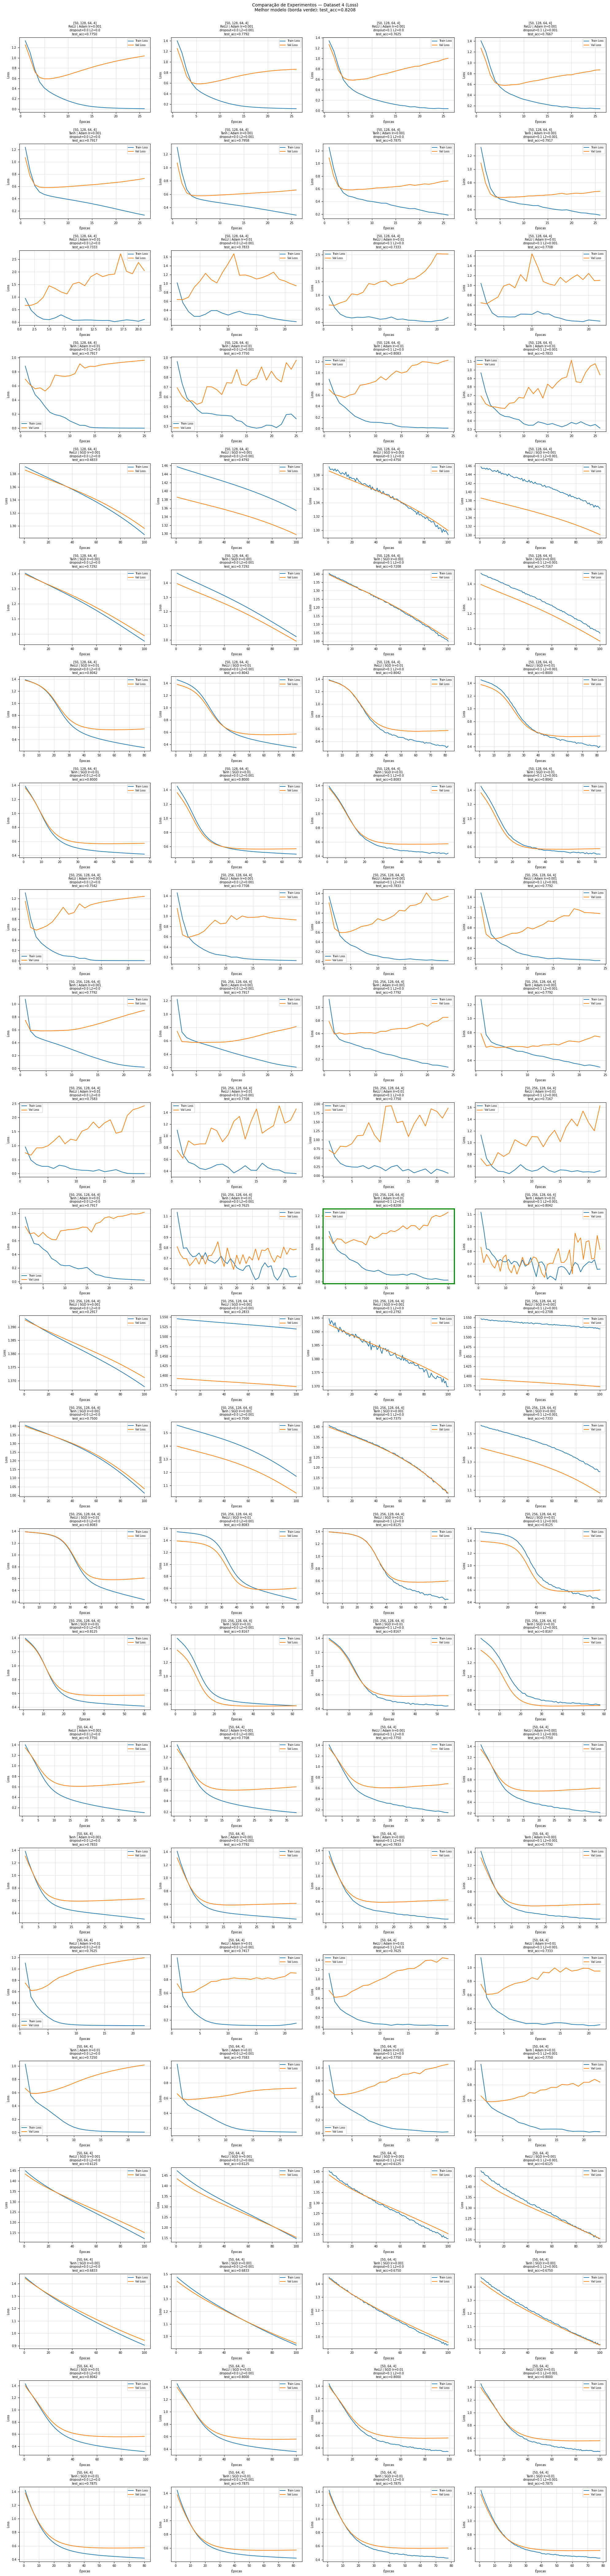

In [ ]:
plot_comparison(results4, cols=4, metric="loss")

As comparaçãos das curvas de loss permitem ver que o otimizador Adam, embora tenha levado à melhor acurácia de teste, teve um treinamento em geral menos estável do que o SGD, e com maior tendência a overfitting quando analisamos as curvas de teste e validação de um mesmo caso. Isso fica particularmente mais acentuado quanto avaliamos a diferença da taxa de aprendizado 0.001 para 0.01.
Também é perceptível que os casos de early stopping mais significativos aconteceram com o otimizador Adam, enquanto o SGD apresentou melhora consistente por muitos mais épocas na maioria dos cenários.

A função de ativação Tanh aparenta ter uma tendência a diminuir o overfitting em relação à função ReLU, levando a uma acurácia de teste maior na maioria dos casos.

O uso de dropout cria uma notável instabilidade em cenários de treinamento que sem ele seriam estáveis, e o ganho de performance em termos da acurácia de teste atribuído a ele foi variável. A regularização L2 também apresentou impacto misto.

No geral, a arquitetura mais simples [50, 64, 4] apresentou os piores resultados de acurácia de teste; embora as duas arquiteturas mais complexas tenham desempenhos ainda piores para uma taxa de aprendizado de 0.001, função de ativação ReLU e otimizador SGD, sua performance é melhor do que mais simples na maiorias dos casos.

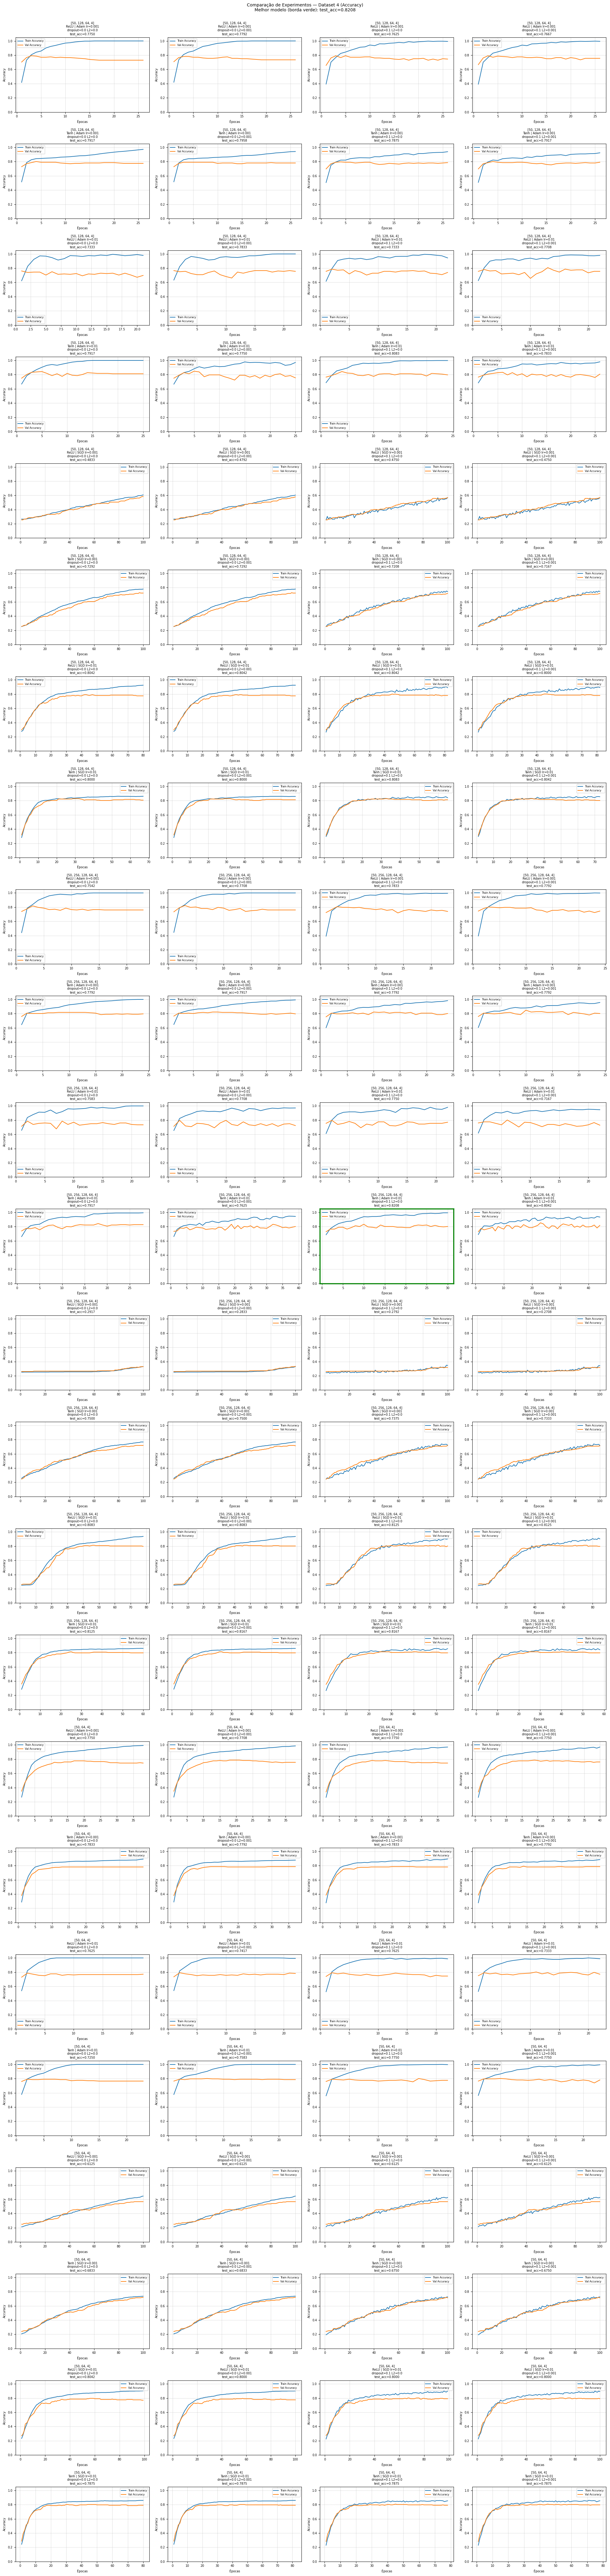

In [ ]:
plot_comparison(results4, cols=4, metric="accuracy")

In [ ]:
top_n = 5
ranked = sorted(results4, key=lambda r: r["test_accuracy"], reverse=True)

print(f"\n{'='*60}")
print(f"\t\tTOP {top_n} MODELOS — Dataset 4")
print(f"{'='*60}")
for rank, res in enumerate(ranked[:top_n], 1):
    cfg = res["config"]
    print(
        f"\n#{rank}  test_acc={res['test_accuracy']:.4f}"
        f"\n\tarquitetura: {cfg['arquitetura']}"
        f"\n\tativação: {cfg['ativacao']}"
        f"\n\totimizador: {cfg['otimizador']}\tlr={cfg['lr']}"
        f"\n\tdropout: {cfg['dropout']}\tL2={cfg['l2_lambda']}"
    )
print(f"\n{'='*60}\n")


		TOP 5 MODELOS — Dataset 4

#1  test_acc=0.8208
	arquitetura: [50, 256, 128, 64, 4]
	ativação: Tanh
	otimizador: Adam	lr=0.01
	dropout: 0.1	L2=0.0

#2  test_acc=0.8167
	arquitetura: [50, 256, 128, 64, 4]
	ativação: Tanh
	otimizador: SGD	lr=0.01
	dropout: 0.0	L2=0.001

#3  test_acc=0.8167
	arquitetura: [50, 256, 128, 64, 4]
	ativação: Tanh
	otimizador: SGD	lr=0.01
	dropout: 0.1	L2=0.0

#4  test_acc=0.8167
	arquitetura: [50, 256, 128, 64, 4]
	ativação: Tanh
	otimizador: SGD	lr=0.01
	dropout: 0.1	L2=0.001

#5  test_acc=0.8125
	arquitetura: [50, 256, 128, 64, 4]
	ativação: ReLU
	otimizador: SGD	lr=0.01
	dropout: 0.1	L2=0.0




### Curiosidade: correlação e influência dos hiperparâmetros

In [ ]:
from scipy.stats import spearmanr, f_oneway

def analyze_hyperparameter_influence(results: list[dict]) -> None:

    todos_encodings = {
        "total de neuronios": lambda c: sum(c["arquitetura"][1:-1]),
        "learning rate": lambda c: c["lr"],
        "dropout": lambda c: c["dropout"],
        "l2 lambda": lambda c: c["l2_lambda"],
        "função de ativacao": lambda c: c["ativacao"],
        "otimizador": lambda c: c["otimizador"],
    }

    ordinais = {"total de neuronios", "learning rate", "dropout", "l2 lambda"}

    test_accs = np.array([r["test_accuracy"] for r in results])

    # --- η² para todas as variáveis ---
    eta2_results = {}
    for param, encoder in todos_encodings.items():
        labels = np.array([encoder(r["config"]) for r in results])
        grupos = [test_accs[labels == l] for l in np.unique(labels)]
        _, pvalue = f_oneway(*grupos)
        grand_mean = test_accs.mean()
        ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in grupos)
        ss_total = sum((x - grand_mean) ** 2 for x in test_accs)
        eta2 = ss_between / ss_total if ss_total > 0 else 0.0
        eta2_results[param] = {"eta2": eta2, "pvalue": pvalue}

    # --- Spearman apenas para ordinais ---
    spearman_results = {}
    for param in ordinais:
        values = [todos_encodings[param](r["config"]) for r in results]
        corr, pvalue = spearmanr(values, test_accs)
        spearman_results[param] = {"corr": corr, "pvalue": pvalue}

    params_ordenados_eta2 = sorted(eta2_results, key=lambda p: eta2_results[p]["eta2"], reverse=True)
    params_ordenados_spearman = [p for p in params_ordenados_eta2 if p in ordinais]

    # --- Plot ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # Subplot 1: eta quadrado (todas as variáveis)
    eta2s = [eta2_results[p]["eta2"] for p in params_ordenados_eta2]
    cores = ["#4C72B0" if p in ordinais else "#C44E52" for p in params_ordenados_eta2]

    bars1 = ax1.barh(params_ordenados_eta2, eta2s, color=cores, edgecolor="white")
    for bar, eta2, p in zip(bars1, eta2s, [eta2_results[p]["pvalue"] for p in params_ordenados_eta2]):
        sig = " *" if p < 0.05 else ""
        ax1.text(eta2 + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{eta2:.2f}{sig}", va="center", ha="left", fontsize=9)

    ax1.set_xlim(0, 1.01)
    ax1.set_xlabel("η² (variância de test_accuracy explicada pelo fator)")
    ax1.set_title("η² — Todas as Variáveis\nAzul = ordinal  |  Vermelho = nominal  |  * p < 0.05")
    ax1.grid(axis="x", alpha=0.3)

    # Subplot 2: Spearman (apenas ordinais)
    corrs = [spearman_results[p]["corr"] for p in params_ordenados_spearman]

    bars2 = ax2.barh(params_ordenados_spearman, corrs, color="#4C72B0", edgecolor="white")
    for bar, corr, p in zip(bars2, corrs, [spearman_results[p]["pvalue"] for p in params_ordenados_spearman]):
        sig = " *" if p < 0.05 else ""
        xpos = corr + (0.02 if corr >= 0 else -0.02)
        ha = "left" if corr >= 0 else "right"
        ax2.text(xpos, bar.get_y() + bar.get_height() / 2,
                 f"{corr:+.2f}{sig}", va="center", ha=ha, fontsize=9)

    ax2.axvline(0, color="black", linewidth=0.8)
    ax2.set_xlim(-1.01, 1.01)
    ax2.set_xlabel("Correlação de Spearman com test_accuracy")
    ax2.set_title("Spearman — Variáveis Ordinais\n* p < 0.05")
    ax2.grid(axis="x", alpha=0.3)

    fig.suptitle("Influência dos Hiperparâmetros na Acurácia de Teste", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

    # --- Tabela texto ---
    print(f"\n{'Hiperparâmetro':<20} {'η²':>6} {'p(η²)':>8} {'Spearman r':>11} {'p(r)':>8}")
    print("-" * 60)
    for p in params_ordenados_eta2:
        sig_eta2 = " *" if eta2_results[p]["pvalue"] < 0.05 else "  "
        eta2_str = f"{eta2_results[p]['eta2']:>6.4f}{sig_eta2}"
        pval_eta2_str = f"{eta2_results[p]['pvalue']:>8.4f}"
        if p in spearman_results:
            sig_sp = " *" if spearman_results[p]["pvalue"] < 0.05 else "  "
            sp_str = f"{spearman_results[p]['corr']:>+11.4f}{sig_sp}"
            pval_sp = f"{spearman_results[p]['pvalue']:>8.4f}"
        else:
            sp_str = f"{'—':>13}"
            pval_sp = f"{'—':>8}"
        print(f"{p:<20} {eta2_str} {pval_eta2_str} {sp_str} {pval_sp}")

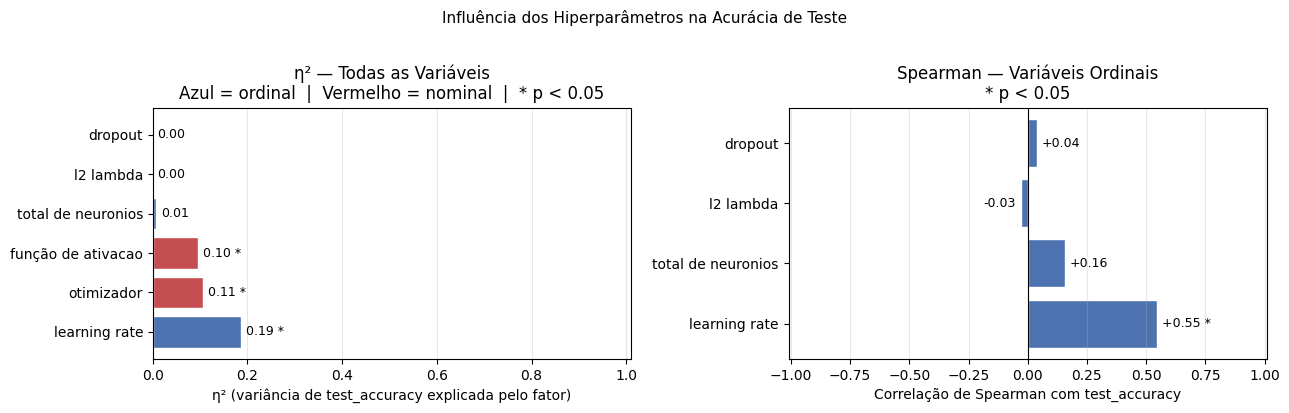


Hiperparâmetro           η²    p(η²)  Spearman r     p(r)
------------------------------------------------------------
learning rate        0.1860 *   0.0000     +0.5453 *   0.0000
otimizador           0.1071 *   0.0011             —        —
função de ativacao   0.0959 *   0.0021             —        —
total de neuronios   0.0077     0.6991     +0.1567     0.1273
l2 lambda            0.0000     0.9523     -0.0286     0.7821
dropout              0.0000     0.9916     +0.0373     0.7186


In [ ]:
analyze_hyperparameter_influence(results4)